In [6]:
import pandas as pd
import re

In [2]:
file_path = '/Users/annasve/Desktop/article_data/biosynthetic_gene_expression_per_condition.xlsx'
bgc_expression = pd.read_excel(file_path)

In [3]:
bgc_expression.head()

,Strain,BGC_ID,Gene_ID,DNPM,ISP2,MA,SoyM,TSB,gluc,gly,malt
0,NBC_01734,1_terpene_NBC_01734,OHB55_06350,2.175151,4.011051,3.823113,3.985171,3.429834,2.998992,3.790951,4.049854
1,NBC_01734,2_NRPS_betalactone_NBC_01734,OHB55_08365,2.911543,1.966670,2.802946,1.774111,2.529994,1.570157,2.060677,2.047154
2,NBC_01734,2_NRPS_betalactone_NBC_01734,OHB55_08370,3.474744,2.659364,3.129204,2.394633,3.003078,2.335253,2.595743,2.726291
3,NBC_01734,2_NRPS_betalactone_NBC_01734,OHB55_08395,3.175957,2.303336,2.984677,1.900976,3.300533,2.131048,2.231835,2.548150
4,NBC_01734,2_NRPS_betalactone_NBC_01734,OHB55_08440,3.890723,2.843695,3.571882,2.444721,3.278767,2.766681,2.729271,2.992903


In [4]:
media_cols = ["DNPM", "ISP2", "MA", "SoyM", "TSB", "gluc", "gly", "malt"]

bgc_avg_expression = (
    bgc_expression.groupby(["Strain", "BGC_ID"], as_index=False)[media_cols]
      .mean()
)

bgc_avg_expression.head()

,Strain,BGC_ID,DNPM,ISP2,MA,SoyM,TSB,gluc,gly,malt
0,NBC_00001,10_NRPS-like_other_nucleoside_NBC_00001,2.052220,2.800726,2.450850,2.577224,1.947189,1.878496,2.492139,1.864145
1,NBC_00001,11_furan_NBC_00001,4.652892,8.989872,4.523973,4.335328,1.313786,9.123664,11.350178,6.424600
2,NBC_00001,12_NI-siderophore_NBC_00001,4.085232,4.739515,4.936622,4.533782,3.174355,3.652043,3.466901,4.379999
3,NBC_00001,13_nucleoside_NBC_00001,4.913477,6.202608,4.793508,5.562214,4.056903,4.475249,3.412159,4.636625
4,NBC_00001,14_terpene_NBC_00001,4.730438,5.470210,5.117656,5.943101,2.672705,3.366341,3.865667,3.898380


In [7]:
def extract_bgc_type(bgc_id):
    # Remove everything before the first underscore and after "_NBC" (or final underscore group)
    bgc_id = str(bgc_id)
    match = re.search(r'^[^_]+_([^_]+(?:_[^_]+)*)_NBC', bgc_id)
    if match:
        return match.group(1)
    else:
        # fallback: between first and last underscore
        parts = bgc_id.split('_')
        return '_'.join(parts[1:-1]) if len(parts) > 2 else bgc_id

bgc_avg_expression["bgc_type"] = bgc_avg_expression["BGC_ID"].apply(extract_bgc_type)


# Replace ", " with "_"
bgc_avg_expression["bgc_type"] = bgc_avg_expression["bgc_type"].str.replace(", ", "_", regex=False)


In [8]:
# Example
# df["bgc_type"] = ['NRPS_T1PKS', 'T1PKS_NRPS', 'terpene', 'NRPS', 'PKS_NRPS_T1PKS']

def normalize_bgc_type(label):
    """Normalize multi-part BGC type strings so that order doesn't matter."""
    if pd.isna(label):
        return label
    # Split by underscores
    parts = label.split("_")
    # Sort alphabetically and rejoin with underscores
    parts_sorted = sorted(parts)
    return "_".join(parts_sorted)

# Apply normalization
bgc_avg_expression["bgc_type_norm"] = bgc_avg_expression["bgc_type"].apply(normalize_bgc_type)


In [10]:
# Assuming df["bgc_type_norm"] already exists from the previous normalization
bgc_avg_expression["bgc_type_final"] = bgc_avg_expression["bgc_type_norm"].apply(
    lambda x: "hybrid" if isinstance(x, str) and x.count("_") > 0 else x
)

In [11]:
# Define the "Other" category list
other_types = [
    'CDPS','LAP','NAGGN','NAPAA','amglyccycl','aminopolycarboxylic-acid',
    'arylpolyene','betalactone','blactam','butyrolactone','crocagin','cyanobactin',
    'ectoine','furan','guanidinotides','hserlactone','indole','lassopeptide',
    'linaridin','melanin','methanobactin','nucleoside','other','phenazine',
    'phosphonate','ranthipeptide','redox-cofactor','sactipeptide','thioamide-NRP',
    'thioamitides','thiopeptide','transAT-PKS', 'RRE-containing', 'oligosaccharide'
]

# Normalize to lowercase for matching, but keep the original capitalization
def standardize_bgc_type(bgc_type):
    if pd.isna(bgc_type):
        return bgc_type
    
    bgc_type_stripped = str(bgc_type).strip()
    bgc_lower = bgc_type_stripped.lower()

    # Group all lanthipeptide-containing into "lanthipeptide"
    if "lanthipeptide" in bgc_lower:
        return "lanthipeptide"

    # If it's one of the predefined "other" types
    elif bgc_lower in [t.lower() for t in other_types]:
        return "other"

    # Otherwise, keep the original capitalization
    else:
        return bgc_type_stripped

# Apply the transformation
bgc_avg_expression["bgc_type_final"] = bgc_avg_expression["bgc_type_final"].apply(standardize_bgc_type)

In [12]:
n_types = bgc_avg_expression["bgc_type_final"].nunique()
n_types

14

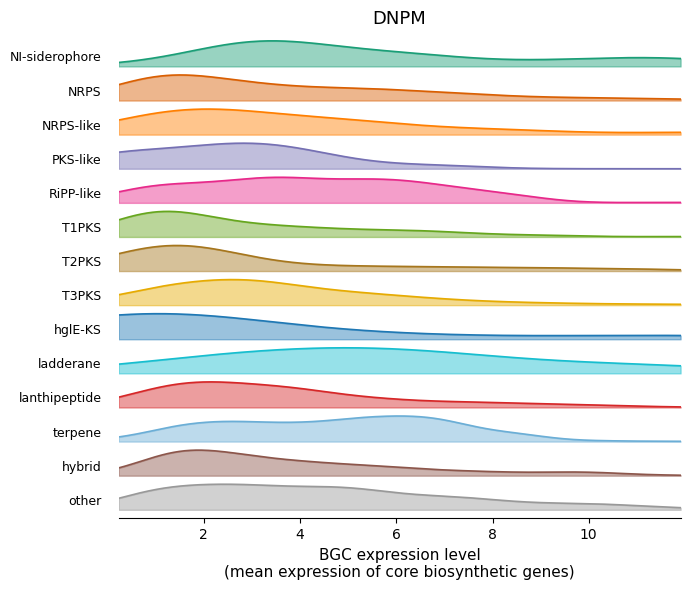

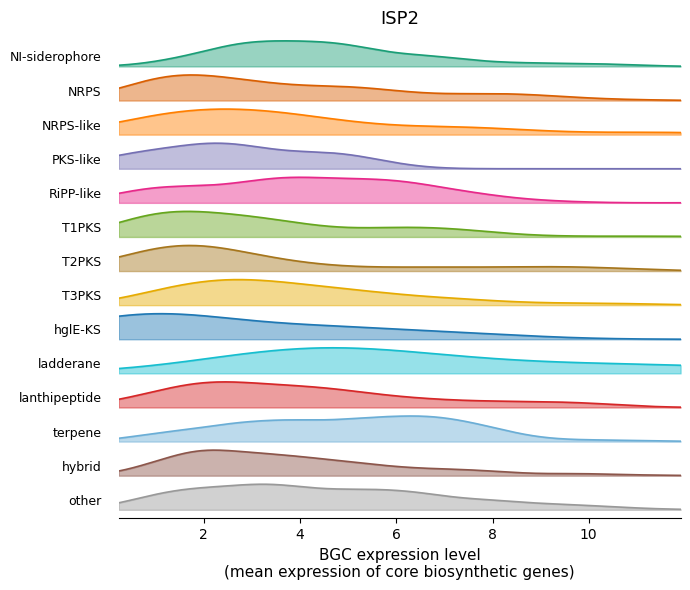

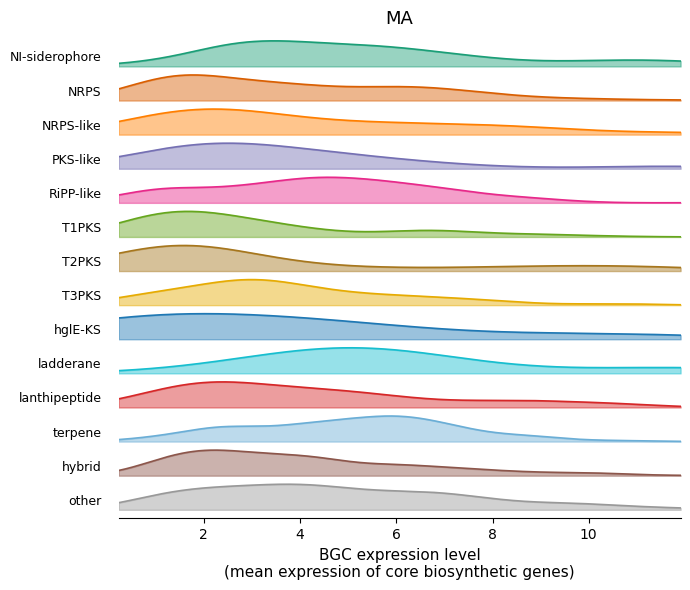

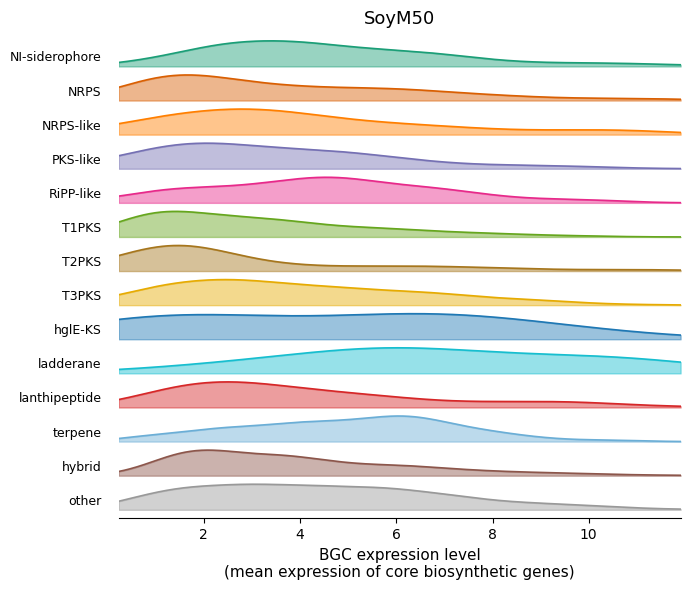

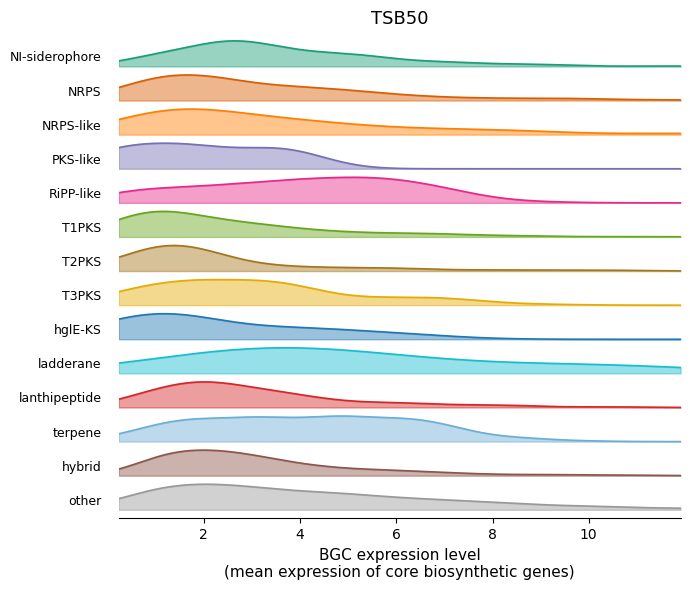

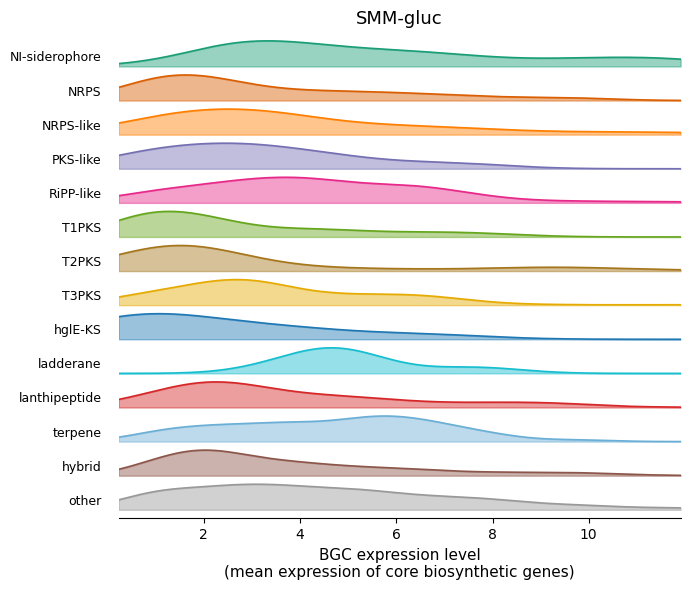

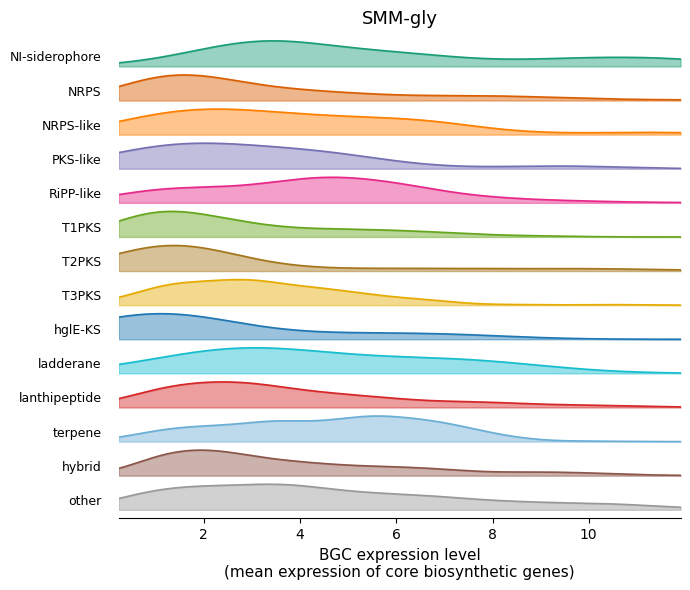

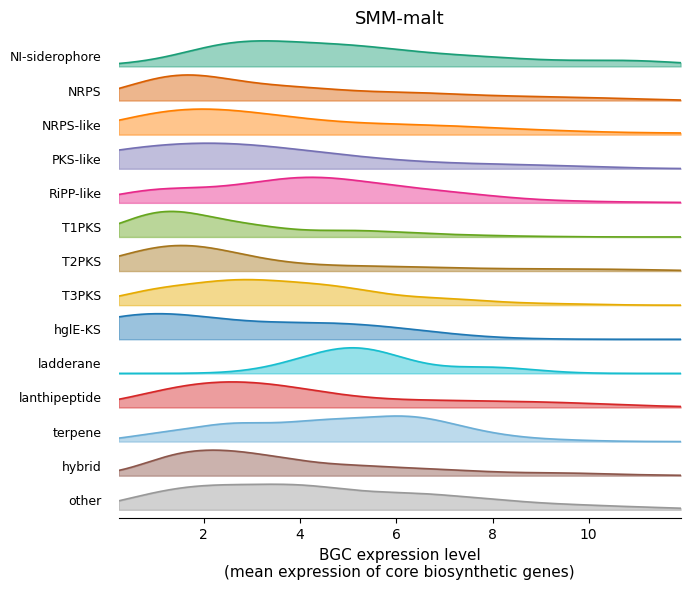

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from pathlib import Path

# =========================================================
# INPUT
# =========================================================

df = bgc_avg_expression.copy()

media_cols = ["DNPM", "ISP2", "MA", "SoyM", "TSB", "gluc", "gly", "malt"]

media_labels = {
    "SoyM": "SoyM50",
    "TSB": "TSB50",
    "gluc": "SMM-gluc",
    "gly": "SMM-gly",
    "malt": "SMM-malt",
    "DNPM": "DNPM",
    "ISP2": "ISP2",
    "MA": "MA",
}

# =========================================================
# BGC TYPE ORDER AND COLORS
# =========================================================

bgc_type_order = [
    "NI-siderophore",
    "NRPS",
    "NRPS-like",
    "PKS-like",
    "RiPP-like",
    "T1PKS",
    "T2PKS",
    "T3PKS",
    "hglE-KS",
    "ladderane",
    "lanthipeptide",
    "oligosaccharide",
    "terpene",
    "hybrid",
    "other",
]

bgc_colors = {
    "NI-siderophore":   "#1b9e77",
    "NRPS":             "#d95f02",
    "NRPS-like":        "#ff7f00",
    "other":            "#999999",
    "PKS-like":         "#7570b3",
    "RiPP-like":        "#e7298a",
    "T1PKS":            "#66a61e",
    "T2PKS":            "#a6761d",
    "T3PKS":            "#e6ab02",
    "hglE-KS":          "#1f78b4",
    "hybrid":           "#8c564b",
    "ladderane":        "#17becf",
    "lanthipeptide":    "#d62728",
    "oligosaccharide":  "#bc80bd",
    "terpene":          "#6baed6",
}

# Keep only BGC types present in your dataframe
bgc_type_order = [
    x for x in bgc_type_order
    if x in df["bgc_type_final"].dropna().unique()
]

# Output folder
outdir = Path("bgc_expression_ridgeline_plots")
outdir.mkdir(exist_ok=True)

# =========================================================
# CONVERT TO LONG FORMAT
# =========================================================

df_long = df.melt(
    id_vars=["Strain", "BGC_ID", "bgc_type", "bgc_type_norm", "bgc_type_final"],
    value_vars=media_cols,
    var_name="Medium",
    value_name="BGC_expression"
)

df_long["Medium_label"] = df_long["Medium"].replace(media_labels)

df_long["BGC_expression"] = pd.to_numeric(
    df_long["BGC_expression"],
    errors="coerce"
)

df_long = df_long.dropna(subset=["BGC_expression", "bgc_type_final"]).copy()

# =========================================================
# RIDGELINE PLOT FUNCTION
# =========================================================

def plot_bgc_expression_ridgeline(
    data,
    medium,
    bgc_type_order,
    bgc_colors,
    x_col="BGC_expression",
    type_col="bgc_type_final",
    xlim=None,
    title=None,
    outfile=None,
    min_n=5,
    alpha=0.45,
):
    """
    Make a ridgeline density plot for one medium.
    Each row is one BGC type.
    """

    sub = data[data["Medium"] == medium].copy()

    if sub.empty:
        print(f"No data for medium: {medium}")
        return

    if xlim is None:
        x_min = np.nanpercentile(data[x_col], 0.5)
        x_max = np.nanpercentile(data[x_col], 99.5)
        xlim = (x_min, x_max)

    x = np.linspace(xlim[0], xlim[1], 400)

    present_types = [
        t for t in bgc_type_order
        if t in sub[type_col].dropna().unique()
    ]

    if len(present_types) == 0:
        print(f"No BGC types found for medium: {medium}")
        return

    fig, ax = plt.subplots(figsize=(7, 6))

    offset_step = 1.0

    # Reverse so the first BGC type in bgc_type_order appears at the top
    for i, bgc_type in enumerate(reversed(present_types)):
        vals = sub.loc[sub[type_col] == bgc_type, x_col].dropna().values

        if len(vals) < min_n:
            continue

        # KDE can fail if all values are identical
        if np.nanstd(vals) == 0:
            continue

        kde = gaussian_kde(vals)
        y = kde(x)

        # Normalize height so rows are visually comparable
        if y.max() > 0:
            y = y / y.max() * 0.75

        baseline = i * offset_step
        color = bgc_colors.get(bgc_type, "#BBBBBB")

        ax.fill_between(
            x,
            baseline,
            baseline + y,
            color=color,
            alpha=alpha
        )

        ax.plot(
            x,
            baseline + y,
            color=color,
            linewidth=1.2
        )

        ax.text(
            xlim[0] - 0.03 * (xlim[1] - xlim[0]),
            baseline + 0.25,
            bgc_type,
            ha="right",
            va="center",
            fontsize=9
        )

    ax.set_xlim(xlim)
    ax.set_ylim(-0.25, len(present_types) * offset_step)

    ax.set_yticks([])
    ax.set_xlabel(
        "BGC expression level\n(mean expression of core biosynthetic genes)",
        fontsize=11
    )

    if title is None:
        title = media_labels.get(medium, medium)

    ax.set_title(title, fontsize=13)
    ax.tick_params(axis="x", labelsize=10)

    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    plt.tight_layout()

    if outfile is not None:
        plt.savefig(outfile, dpi=400, bbox_inches="tight")

    plt.show()

# =========================================================
# MAKE ONE PLOT PER MEDIUM
# =========================================================

# Use the same x-axis range for all media
global_xlim = (
    np.nanpercentile(df_long["BGC_expression"], 0.5),
    np.nanpercentile(df_long["BGC_expression"], 99.5)
)

for medium in media_cols:
    plot_bgc_expression_ridgeline(
        data=df_long,
        medium=medium,
        bgc_type_order=bgc_type_order,
        bgc_colors=bgc_colors,
        xlim=global_xlim,
        title=media_labels.get(medium, medium),
        outfile=outdir / f"bgc_expression_ridgeline_{media_labels.get(medium, medium)}.png",
        alpha=0.45
    )

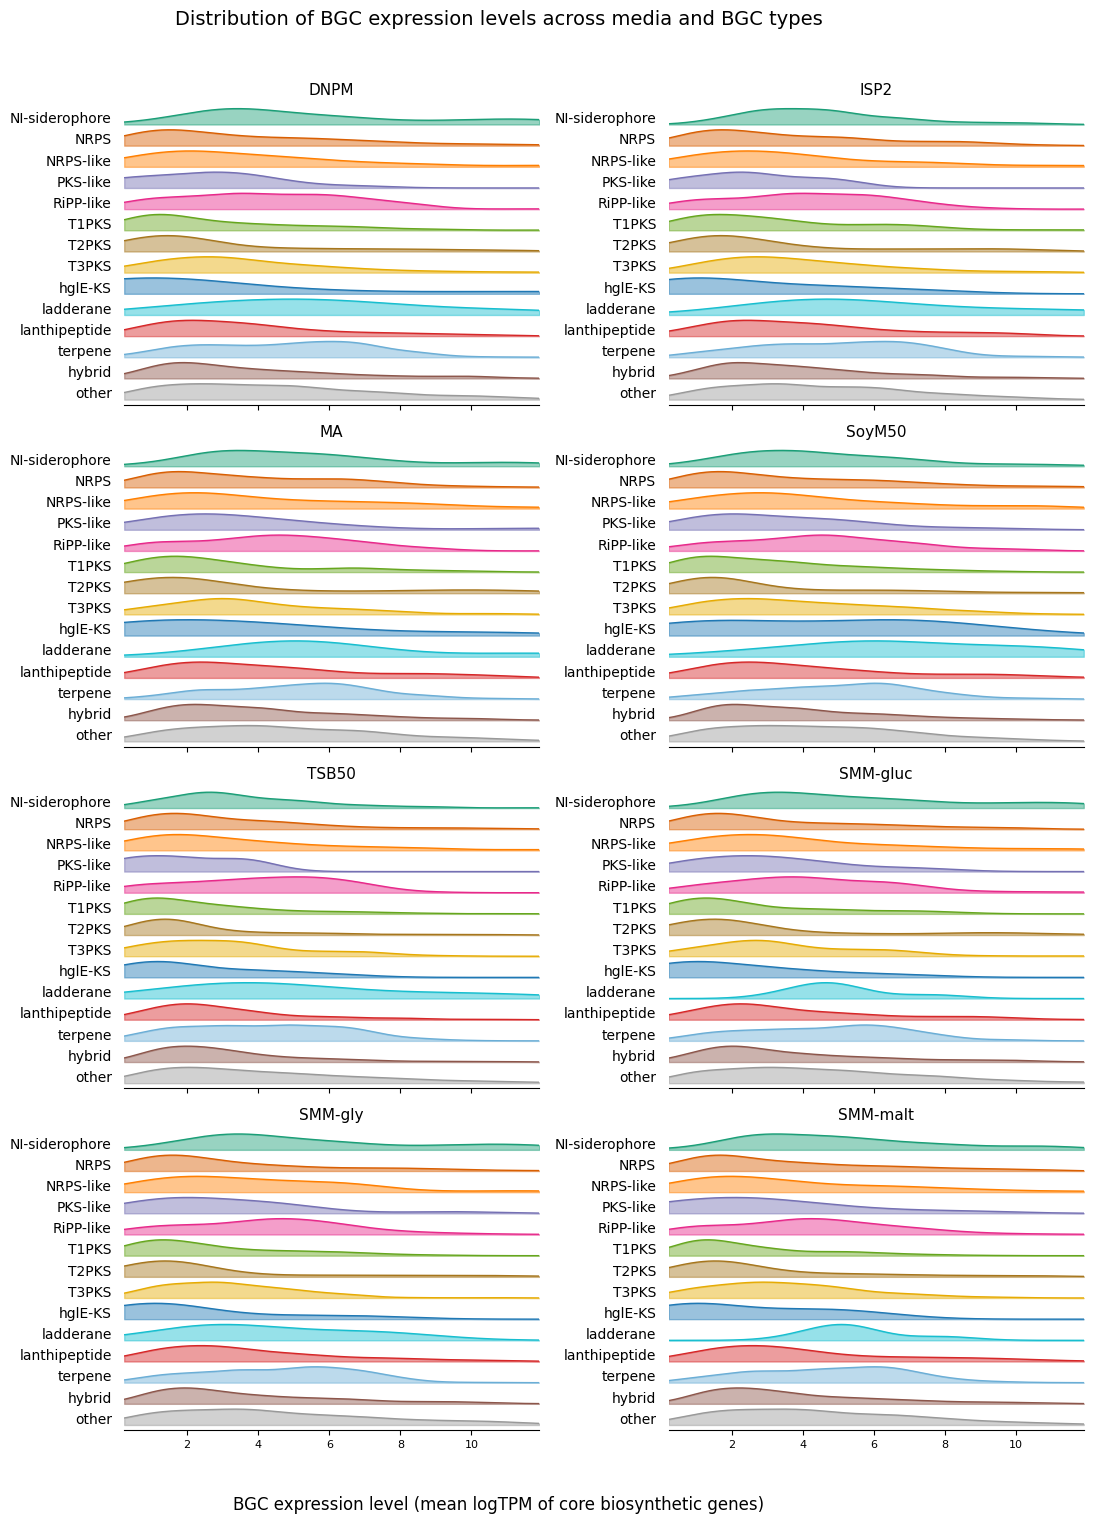

Saved combined figure to: bgc_expression_ridgeline_all_media_4x2.png


In [19]:
# =========================================================
# COMBINED 4 x 2 RIDGELINE FIGURE
# =========================================================

def draw_bgc_expression_ridgeline_on_ax(
    ax,
    data,
    medium,
    bgc_type_order,
    bgc_colors,
    x_col="BGC_expression",
    type_col="bgc_type_final",
    xlim=None,
    min_n=5,
    alpha=0.45,
):
    """
    Draw one ridgeline density plot on an existing axis.
    """

    sub = data[data["Medium"] == medium].copy()

    if sub.empty:
        ax.set_title(media_labels.get(medium, medium), fontsize=11)
        ax.text(
            0.5,
            0.5,
            "No data",
            ha="center",
            va="center",
            transform=ax.transAxes
        )
        ax.axis("off")
        return

    if xlim is None:
        x_min = np.nanpercentile(data[x_col], 0.5)
        x_max = np.nanpercentile(data[x_col], 99.5)
        xlim = (x_min, x_max)

    x = np.linspace(xlim[0], xlim[1], 400)

    present_types = [
        t for t in bgc_type_order
        if t in sub[type_col].dropna().unique()
    ]

    offset_step = 1.0
    plotted_count = 0

    # Reverse so first BGC type in bgc_type_order appears at the top
    for i, bgc_type in enumerate(reversed(present_types)):
        vals = sub.loc[sub[type_col] == bgc_type, x_col].dropna().values

        if len(vals) < min_n:
            continue

        # KDE can fail if all values are identical
        if np.nanstd(vals) == 0:
            continue

        kde = gaussian_kde(vals)
        y = kde(x)

        # Normalize height so rows are visually comparable
        if y.max() > 0:
            y = y / y.max() * 0.75

        baseline = i * offset_step
        color = bgc_colors.get(bgc_type, "#BBBBBB")

        ax.fill_between(
            x,
            baseline,
            baseline + y,
            color=color,
            alpha=alpha
        )

        ax.plot(
            x,
            baseline + y,
            color=color,
            linewidth=1.0
        )

        ax.text(
            xlim[0] - 0.03 * (xlim[1] - xlim[0]),
            baseline + 0.25,
            bgc_type,
            ha="right",
            va="center",
            fontsize=10
        )

        plotted_count += 1

    ax.set_xlim(xlim)
    ax.set_ylim(-0.25, len(present_types) * offset_step)

    ax.set_title(media_labels.get(medium, medium), fontsize=11)
    ax.set_yticks([])
    ax.tick_params(axis="x", labelsize=8)

    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    if plotted_count == 0:
        ax.text(
            0.5,
            0.5,
            "No sufficient data",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=8
        )


# =========================================================
# MAKE COMBINED FIGURE
# =========================================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(12, 16),
    sharex=True
)

axes = axes.flatten()

for ax, medium in zip(axes, media_cols):
    draw_bgc_expression_ridgeline_on_ax(
        ax=ax,
        data=df_long,
        medium=medium,
        bgc_type_order=bgc_type_order,
        bgc_colors=bgc_colors,
        xlim=global_xlim,
        min_n=5,
        alpha=0.45
    )

# Hide unused axes if any
for ax in axes[len(media_cols):]:
    ax.axis("off")

fig.suptitle(
    "Distribution of BGC expression levels across media and BGC types",
    fontsize=14,
    y=0.995
)

fig.supxlabel(
    "BGC expression level (mean logTPM of core biosynthetic genes)",
    fontsize=12,
    y=0.055
)

plt.tight_layout(rect=[0.08, 0.065, 1, 0.98])

combined_outfile = "bgc_expression_ridgeline_all_media_4x2.png"
plt.savefig(combined_outfile, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved combined figure to: {combined_outfile}")

In [20]:
bgc_avg_expression

,Strain,BGC_ID,DNPM,ISP2,MA,SoyM,TSB,gluc,gly,malt,bgc_type,bgc_type_norm,bgc_type_final
0,NBC_00001,10_NRPS-like_other_nucleoside_NBC_00001,2.052220,2.800726,2.450850,2.577224,1.947189,1.878496,2.492139,1.864145,NRPS-like_other_nucleoside,NRPS-like_nucleoside_other,hybrid
1,NBC_00001,11_furan_NBC_00001,4.652892,8.989872,4.523973,4.335328,1.313786,9.123664,11.350178,6.424600,furan,furan,other
2,NBC_00001,12_NI-siderophore_NBC_00001,4.085232,4.739515,4.936622,4.533782,3.174355,3.652043,3.466901,4.379999,NI-siderophore,NI-siderophore,NI-siderophore
3,NBC_00001,13_nucleoside_NBC_00001,4.913477,6.202608,4.793508,5.562214,4.056903,4.475249,3.412159,4.636625,nucleoside,nucleoside,other
4,NBC_00001,14_terpene_NBC_00001,4.730438,5.470210,5.117656,5.943101,2.672705,3.366341,3.865667,3.898380,terpene,terpene,terpene
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3985,NBC_01815,5_NI-siderophore_NBC_01815,4.250500,4.010117,5.768043,6.256433,2.747685,7.395006,8.911628,9.718436,NI-siderophore,NI-siderophore,NI-siderophore
3986,NBC_01815,6_T2PKS_NBC_01815,2.007454,1.350837,1.396239,1.323844,1.665701,1.867437,1.489366,1.353242,T2PKS,T2PKS,T2PKS
3987,NBC_01815,7_RiPP-like_NBC_01815,7.023913,6.111471,4.933062,10.342943,6.122886,6.047555,5.546558,5.899081,RiPP-like,RiPP-like,RiPP-like
3988,NBC_01815,8_terpene_NBC_01815,7.723913,7.241013,7.262236,6.308092,8.067368,6.647379,4.835763,6.540297,terpene,terpene,terpene


In [21]:
import numpy as np
import pandas as pd

# Your dataframe
df_tau = bgc_avg_expression.copy()

media_cols = ["DNPM", "ISP2", "MA", "SoyM", "TSB", "gluc", "gly", "malt"]

# Make sure media columns are numeric
for col in media_cols:
    df_tau[col] = pd.to_numeric(df_tau[col], errors="coerce")

def calculate_tau(row, media_cols):
    """
    Tau specificity index across media.
    
    tau = sum(1 - x_i) / (n - 1)
    where x_i = expression_i / max(expression)
    
    tau close to 0 = broad expression
    tau close to 1 = medium-specific expression
    """
    values = row[media_cols].astype(float).values
    
    # Remove NaN values
    values = values[~np.isnan(values)]
    
    # Need at least 2 media
    if len(values) < 2:
        return np.nan
    
    max_expr = np.max(values)
    
    # If expression is zero or negative everywhere, tau is undefined
    if max_expr <= 0:
        return np.nan
    
    x = values / max_expr
    tau = np.sum(1 - x) / (len(values) - 1)
    
    return tau

# Calculate tau for each BGC
df_tau["tau_medium_specificity"] = df_tau.apply(
    calculate_tau,
    axis=1,
    media_cols=media_cols
)

# Identify medium with maximum expression
df_tau["max_expression_medium"] = df_tau[media_cols].idxmax(axis=1)

# Maximum expression value
df_tau["max_expression_value"] = df_tau[media_cols].max(axis=1)

# Optional simple classification
def classify_tau(tau):
    if pd.isna(tau):
        return np.nan
    elif tau < 0.25:
        return "broadly expressed"
    elif tau < 0.75:
        return "medium-biased"
    else:
        return "medium-specific"

df_tau["tau_class"] = df_tau["tau_medium_specificity"].apply(classify_tau)

df_tau.head()

,Strain,BGC_ID,DNPM,ISP2,MA,SoyM,TSB,gluc,gly,malt,bgc_type,bgc_type_norm,bgc_type_final,tau_medium_specificity,max_expression_medium,max_expression_value,tau_class
0,NBC_00001,10_NRPS-like_other_nucleoside_NBC_00001,2.052220,2.800726,2.450850,2.577224,1.947189,1.878496,2.492139,1.864145,NRPS-like_other_nucleoside,NRPS-like_nucleoside_other,hybrid,0.221515,ISP2,2.800726,broadly expressed
1,NBC_00001,11_furan_NBC_00001,4.652892,8.989872,4.523973,4.335328,1.313786,9.123664,11.350178,6.424600,furan,furan,other,0.504550,gly,11.350178,medium-biased
2,NBC_00001,12_NI-siderophore_NBC_00001,4.085232,4.739515,4.936622,4.533782,3.174355,3.652043,3.466901,4.379999,NI-siderophore,NI-siderophore,NI-siderophore,0.188808,MA,4.936622,broadly expressed
3,NBC_00001,13_nucleoside_NBC_00001,4.913477,6.202608,4.793508,5.562214,4.056903,4.475249,3.412159,4.636625,nucleoside,nucleoside,other,0.266435,ISP2,6.202608,medium-biased
4,NBC_00001,14_terpene_NBC_00001,4.730438,5.470210,5.117656,5.943101,2.672705,3.366341,3.865667,3.898380,terpene,terpene,terpene,0.299995,SoyM,5.943101,medium-biased


In [22]:
df_tau["tau_medium_specificity"].describe()

count    3990.000000
mean        0.339907
std         0.162894
min         0.028898
25%         0.214055
50%         0.313100
75%         0.437749
max         0.965799
Name: tau_medium_specificity, dtype: float64

In [23]:
df_tau.to_excel('avg_bgc_expression_tau.xlsx')

In [24]:
df_tau["tau_class"].value_counts()

tau_class
medium-biased        2559
broadly expressed    1357
medium-specific        74
Name: count, dtype: int64

In [25]:
tau_by_type = (
    df_tau.groupby("bgc_type_final")
    .agg(
        n_BGCs=("BGC_ID", "nunique"),
        mean_tau=("tau_medium_specificity", "mean"),
        median_tau=("tau_medium_specificity", "median")
    )
    .reset_index()
    .sort_values("median_tau", ascending=False)
)

tau_by_type

,bgc_type_final,n_BGCs,mean_tau,median_tau
3,PKS-like,17,0.456715,0.429831
8,hglE-KS,9,0.467827,0.412247
6,T2PKS,85,0.423841,0.397327
5,T1PKS,139,0.415483,0.390942
2,NRPS-like,81,0.369548,0.355119
1,NRPS,204,0.377291,0.348179
11,lanthipeptide,193,0.356089,0.335541
12,other,855,0.341622,0.322810
4,RiPP-like,194,0.349191,0.320209
9,hybrid,1156,0.348870,0.315904
